In [1]:
class My_LR():
    def __init__(self):
        self.m = 0
        self.b = 0

    def fit(self, X_train, y_train):
        num = 0
        den = 0
        X_train = X_train.squeeze()
        y_train = y_train.squeeze()
        x_mean = X_train.mean()
        y_mean = y_train.mean()

        for i in range(X_train.shape[0]):
            x_val = X_train.iloc[i]
            y_val = y_train.iloc[i]
            num += (x_val - x_mean) * (y_val - y_mean)
            den += (x_val - x_mean) * (x_val - x_mean)

        self.m = num / den
        self.b = y_mean - (self.m * x_mean)

        print('Slope (m): ',self.m)
        print('Intercept (b): ',self.b)

    def predict(self, X_test):
        X_test = X_test.squeeze()
        return (self.m * X_test) + self.b

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('D:/Important Files/Machine Learning/Datasets/Placement Data.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package')

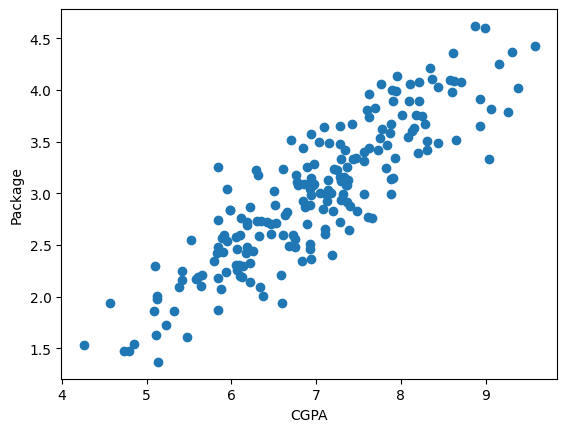

In [4]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')

In [5]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [7]:
X_train.shape

(160, 1)

In [8]:
lr = My_LR()

lr.fit(X_train, y_train)

Slope (m):  0.5579519734250721
Intercept (b):  -0.8961119222429152


In [9]:
lr.predict(X_test)

112    3.891116
29     3.093245
182    2.384646
199    2.574349
193    1.653729
85     1.776478
10     2.072193
54     2.931439
115    3.762787
35     2.937018
12     4.091979
92     3.511709
13     2.970495
126    2.401384
174    3.188097
2      3.467073
44     1.943864
3      3.243892
113    2.976075
14     3.416857
23     2.557611
25     3.165778
6      2.858905
134    3.121142
165    3.684674
173    2.870064
45     3.494970
65     3.344323
48     3.919014
122    1.960602
178    3.651197
64     3.210415
9      3.740469
57     2.786371
78     2.780792
71     3.271789
128    3.528447
176    2.613406
131    2.658042
53     2.713837
Name: cgpa, dtype: float64

Text(0, 0.5, 'Package')

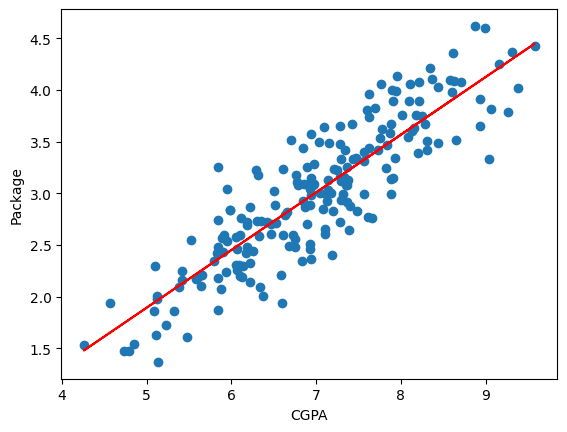

In [10]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package')

Text(0, 0.5, 'Package')

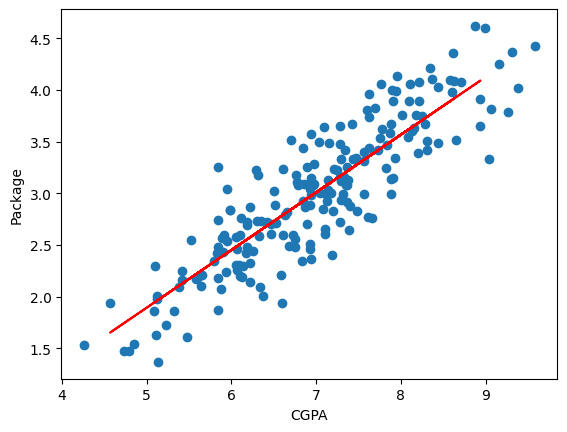

In [11]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_test, lr.predict(X_test), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package')